<a href="https://colab.research.google.com/github/tnc-br/ddf-isoscapes/blob/rmse-test/RMSE_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Variational model

Find the mean/variance of O18 ratios (as well as N15 and C13 in the future) at a particular lat/lon across Brazil.

In [ ]:
import importlib
from datetime import datetime
import sys
import os

# Import libraries required

In [ ]:
!if [ ! -d "/content/ddf_common_stub" ] ; then git clone -b test https://github.com/tnc-br/ddf_common_stub.git; fi
sys.path.append("/content/ddf_common_stub/")
import ddfimport
ddfimport.ddf_import_common(email='', branch_name="rmse")

executing checkout_branch rmse...
Branch rmse already checked out.
Remember to reload your imports with `importlib.reload(module)`.
b"fatal: destination path 'ddf_common' already exists and is not an empty directory.\nRepository already exists.\n"
b'Already up to date.\n'
b''
rmse branch checked out at "/content/gdrive/MyDrive/rmse/ddf_common". You may now use ddf_common imports and change common files.


interactive(children=(Text(value='required', description='Commit Msg', placeholder='Enter commit message'), Bu…

In [ ]:
import train_variational_inference_model as tvim
import raster
import eeddf
import importlib
import model
import dataset

importlib.reload(model)
importlib.reload(dataset)

# Leave test_environment=True. Experiments must be done in test.
eeddf.initialize_ddf(test_environment=True)

# Model configuration

In [ ]:
params = tvim.VIModelTrainingParams(
    training_id = "foil-t-ruru-cvf-bigepoch-foilage", #@param
    num_epochs = 2000, #@param
    num_layers = 3, #@param
    num_nodes_per_layer = 20, #@param
    training_batch_size = 64, #@param
    learning_rate = 0.001, #@param
    mean_label = "d18O_cel_mean", #@param
    var_label = "d18O_cel_variance", #@param
    early_stopping_patience = 200, #@param
    double_sided_kl = True, #@param
    kl_num_samples_from_pred_dist = None, #@param
    dropout_rate = 0, #@param
    activation_func = "relu", #@param
    features_to_standardize = ['lat', 'long', 'VPD', 'RH', 'PET', 'DEM', 'PA', 'Mean Annual Temperature', 'Mean Annual Precipitation', 'Iso_Oxi_Stack_mean_TERZER', 'isoscape_fullmodel_d18O_prec_REGRESSION', 'brisoscape_mean_ISORIX', 'd13C_cel_mean', 'd13C_cel_var', 'ordinary_kriging_linear_d18O_predicted_mean', 'ordinary_kriging_linear_d18O_predicted_variance', 'd13C_foliar', 'd15N_foliar', 'd15N_soil'], #@param
    features_to_passthrough = [], #@param
    resolution_x = 1024, #@param
    resolution_y = 1024, #@param
    n_cv_folds = 10, #@param
    min_steps = 100, #@param
    tags = ["author:ruru", "ViNN", "small_epochs"], #@param
    foo = "bar"
)



In [ ]:
eval_params = tvim.VIModelEvalParams(
    samples_per_location = 5, #@param
    precision_target = 0.95, #@param
    recall_target = None, #@param
    start_max_fraud_radius= 6, #@param
    end_max_fraud_radius = 3000, #@param
    radius_pace = 100, #@param
    trusted_buffer_radius = 5, #@param
    elements_to_eval = ['d18O_cel'], #@param
)

# Data configuration

In [ ]:
from google.colab import drive
drive.mount(raster.GDRIVE_BASE)

# REQUIREMENTS:

# 1) Column names must match features_to_standardize, features_to_passthrough
# 2) Label columns in particular must match var_label and mean_label.
#
# If you used the data ingestion notebook (ingestion.ipynb) then this
# should be set up for you already.

# TRAINING FILE PARAMS
DATABASE_DIR = raster.GDRIVE_BASE + raster.SAMPLE_DATA_BASE
TRAINING_SET_FILE = 'canonical/12_16.csv' #@param
# VALIDATION_SET_FILE = 'demo_validation_fixed_grouped.csv' #@param
# TEST_SET_FILE = 'demo_test_fixed_grouped.csv' #@param

# EVAL FILE PARAMS
EVAL_DATASET = 'demo_test_fixed_grouped.csv' #@param
ORIGINAL_DATASET = 'canonical/2023_06_23_Results_Google.csv' #@param

fileset = {
    'TRAIN' : os.path.join(DATABASE_DIR, TRAINING_SET_FILE),
    # 'TEST' : os.path.join(DATABASE_DIR, TEST_SET_FILE),
    # 'VALIDATION' : os.path.join(DATABASE_DIR, VALIDATION_SET_FILE),
    'EVAL' : os.path.join(DATABASE_DIR, EVAL_DATASET),
    'ORIGINAL' : os.path.join(DATABASE_DIR, ORIGINAL_DATASET)
}

MODEL_SAVE_LOCATION = raster.get_model_path(params.training_id + ".keras")
ISOSCAPE_SAVE_LOCATION = raster.get_raster_path(params.training_id+".tiff")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# Train the model

foil-t-ruru-cvf-bigepoch-foilage
Training fold #0 ||| (train_index_start: [ 25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42
  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60
  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78
  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96
  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114
 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132
 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150
 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168
 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186
 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204
 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222
 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240
 241 242 243 244 245 246 247 248], val_index_start

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 20)        │        400 │ input_layer_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 20)        │        420 │ dense_45[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 20)        │        420 │ dense_46[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ var_output (Dense)  │ (None, 1)         │         21 │ dense_47[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean_output (Dense) │ (None, 1)         │         21 │ dense_47[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_19         │ (None, 1)         │          0 │ var_output[0][0]  │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_18         │ (None, 1)         │          0 │ mean_output[0][0] │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 1)         │          0 │ multiply_19[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 1)         │          0 │ multiply_18[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_29 (Cast)      │ (None, 1)         │          0 │ add_19[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_30 (Cast)      │ (None, 1)         │          0 │ add_18[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softplus_layer_5    │ (None, 1)         │          0 │ cast_29[0][0]     │
│ (SoftplusLayer)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 2)         │          0 │ cast_30[0][0],    │
│ (Concatenate)       │                   │            │ softplus_layer_5… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,282 (5.01 KB)

 Trainable params: 1,282 (5.01 KB)

...

 Non-trainable params: 0 (0.00 B)

Epoch 1/2000


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - loss: 2.7483 - val_loss: 2.6771
Epoch 2/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 2.5417 - val_loss: 2.5181
Epoch 3/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 2.4013 - val_loss: 2.3927
Epoch 4/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 2.2898 - val_loss: 2.2944
Epoch 5/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 2.2065 - val_loss: 2.2269
Epoch 6/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 2.1500 - val_loss: 2.1766
Epoch 7/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 2.1050 - val_loss: 2.1284
Epoch 8/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 2.0595 - val_loss: 2.0850
Epoch 9/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 2.0157 - val_loss: 2.0455
Epoch 10/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 1.9740 - val_loss: 2.0127
Epoch 11/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 1.9381 - val_loss: 1.9863
Epoch 12/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 1.9088 - val_lo

/content/gdrive/MyDrive/rmse/ddf_common/model.py:420: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim((0, 10))


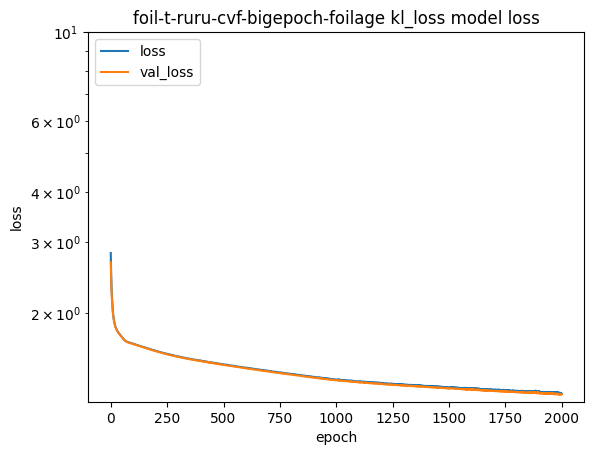

Val loss: 1.2547707557678223
Train loss: 1.2635750770568848
Driver: GTiff/GeoTIFF
Size is 941 x 937 x 12
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0000000000241, 5.29166666665704)
Pixel Size = (0.04166666666665718, -0.04166666666667143)
Driver: GTiff/GeoTIFF
Size is 941 x 937 x 12
Projection is GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Origin = (-74.0000000000241, 5.29166666665704)
Pixel Size = (0.04166666666665718, -0.04166666666667143)
Driver: 

ValueError: Geotiff inputs don't match the inputs expected by the model

In [ ]:
EVAL_ONLY = False #@param{type:'boolean'}
ENABLE_FRAUD_DETECTION_EVAL = False #@param{type:'boolean'}
res = tvim.train_variational_inference_model(params, eval_params, fileset, ISOSCAPE_SAVE_LOCATION, MODEL_SAVE_LOCATION, eval_only=EVAL_ONLY, enable_fraud_detection_eval=ENABLE_FRAUD_DETECTION_EVAL)

# Optional Rendering

In [ ]:
from matplotlib import rc
rc('animation', html='jshtml')

means_isoscape = raster.load_raster(ISOSCAPE_SAVE_LOCATION, use_only_band_index=0)
raster.animate(means_isoscape,  1, 1)

In [ ]:
vars_isoscape = raster.load_raster(ISOSCAPE_SAVE_LOCATION, use_only_band_index=1)
raster.animate(vars_isoscape,  1, 1)